# Vocabulary Inspection

Ispezione del vocabolario LDA: frequenze, soglie `no_below`/`no_above`, parole filtrate per alias, bigram candidati.

Richiede `spacy` e `en_core_web_sm`. Se non installati:
```
pip install spacy
python -m spacy download en_core_web_sm
```

In [3]:
! pip install matplotlib
! pip install spacy
! pip install seaborn

import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

sns.set_context('talk')
%matplotlib inline

BASE_DIR = Path('.').resolve().parent
LDA_DIR  = BASE_DIR / 'data/topic_modeling'
CACHE    = LDA_DIR / 'vocab_cache.pkl'

print(f'Base dir: {BASE_DIR}')

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Base dir: C:\Users\marco\Desktop\Reddit-tech-stocks-NLP


## 1. Carica chunk e tokenizza con spaCy

Stessa pipeline di `run_lda.py`: lemmatizzazione, filtro POS, rimozione stopwords, token >= 3 caratteri.

I token vengono salvati in `vocab_cache.pkl` così le run successive sono istantanee.

In [4]:
ALLOWED_POS   = {'NOUN', 'VERB', 'ADJ', 'ADV'}
MIN_TOKEN_LEN = 3

if CACHE.exists():
    print('[INFO] Loading cached token lists...')
    with open(CACHE, 'rb') as f:
        token_lists = pickle.load(f)
    print(f'[INFO] Loaded {len(token_lists):,} documents from cache.')
else:
    print('[INFO] Cache not found — running spaCy preprocessing...')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

    df = pd.read_csv(BASE_DIR / 'data/corpus_building/chunks_lda_v1.csv', low_memory=False)
    texts = df['chunk_text'].astype(str).tolist()
    print(f'[INFO] Processing {len(texts):,} chunks...')

    token_lists = []
    batch_size  = 100
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        for doc in nlp.pipe(batch, batch_size=batch_size):
            tokens = [
                token.lemma_.lower()
                for token in doc
                if (
                    token.pos_ in ALLOWED_POS
                    and not token.is_stop
                    and not token.is_punct
                    and not token.is_space
                    and len(token.lemma_) >= MIN_TOKEN_LEN
                    and token.lemma_.isalpha()
                )
            ]
            token_lists.append(tokens)
        if i % 1000 == 0:
            print(f'  {min(i+batch_size, len(texts)):,}/{len(texts):,}')

    with open(CACHE, 'wb') as f:
        pickle.dump(token_lists, f)
    print(f'[INFO] Done. Cache saved -> {CACHE.name}')

print(f'Total tokens (raw): {sum(len(t) for t in token_lists):,}')
print(f'Documents:          {len(token_lists):,}')

[INFO] Cache not found — running spaCy preprocessing...
[INFO] Processing 6,507 chunks...
  100/6,507
  1,100/6,507
  2,100/6,507
  3,100/6,507
  4,100/6,507
  5,100/6,507
  6,100/6,507
[INFO] Done. Cache saved -> vocab_cache.pkl
Total tokens (raw): 1,658,601
Documents:          6,507


## 2. Frequenza di documento (df) per ogni parola

`df` = numero di chunk in cui la parola appare almeno una volta.

In [5]:
n_docs = len(token_lists)

df_counter = Counter()
for tokens in token_lists:
    for word in set(tokens):
        df_counter[word] += 1

df_series = pd.Series(df_counter, name='df').sort_values(ascending=False)
print(f'Unique tokens (no filter): {len(df_series):,}')
print(f'\nTop 30 by document frequency:')
print(df_series.head(30).to_string())

Unique tokens (no filter): 29,124

Top 30 by document frequency:
nvda       6399
buy        6326
call       6033
sell       5794
amd        5544
market     5446
put        5098
stock      5001
think      4967
get        4916
pltr       4829
day        4773
today      4608
money      4581
good       4575
time       4558
week       4371
fuck       4230
earning    4205
hold       4139
year       4045
look       3984
need       3979
share      3955
know       3926
right      3805
shit       3693
company    3685
pump       3595
price      3539


## 3. Effetto delle soglie `no_below` e `no_above`

In [6]:
DICT_NO_ABOVE = 0.50
df_pct = df_series / n_docs

for no_below in [3, 5, 10, 15]:
    kept = df_series[(df_series >= no_below) & (df_pct <= DICT_NO_ABOVE)]
    print(f'no_below={no_below:2d}  →  {len(kept):5,} tokens in vocab  '
          f'(dropped low-freq: {(df_series < no_below).sum():,} | '
          f'dropped high-freq: {(df_pct > DICT_NO_ABOVE).sum():,})')

no_below= 3  →  12,032 tokens in vocab  (dropped low-freq: 17,057 | dropped high-freq: 35)
no_below= 5  →  9,096 tokens in vocab  (dropped low-freq: 19,993 | dropped high-freq: 35)
no_below=10  →  6,315 tokens in vocab  (dropped low-freq: 22,774 | dropped high-freq: 35)
no_below=15  →  5,094 tokens in vocab  (dropped low-freq: 23,995 | dropped high-freq: 35)


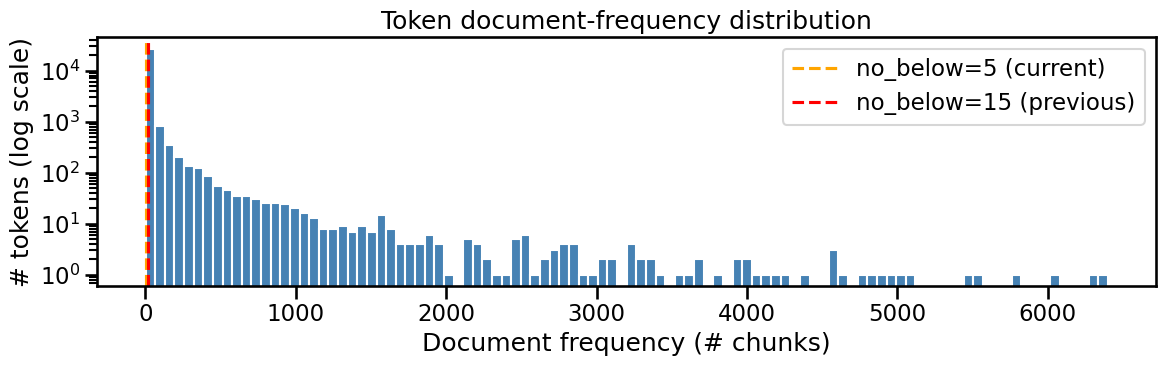

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_series.values, bins=100, log=True, color='steelblue', edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', label='no_below=5 (current)')
ax.axvline(15, color='red',    linestyle='--', label='no_below=15 (previous)')
ax.set_xlabel('Document frequency (# chunks)')
ax.set_ylabel('# tokens (log scale)')
ax.set_title('Token document-frequency distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Parole guadagnate abbassando no_below da 15 a 5
gained = df_series[(df_series >= 5) & (df_series < 15)].sort_values(ascending=False)
print(f'Parole guadagnate abbassando no_below 15→5: {len(gained):,}')
print('\nTop 50 gained words (by df):')
print(gained.head(50).to_string())

Parole guadagnate abbassando no_below 15→5: 4,002

Top 50 gained words (by df):
bollinger        14
amaze            14
notably          14
vary             14
commission       14
merging          14
bluff            14
abroad           14
scalper          14
gotcha           14
transistor       14
irresponsible    14
unstable         14
granny           14
hmmmm            14
dismiss          14
kudo             14
parrot           14
neo              14
aye              14
ink              14
spyg             14
daughter         14
incur            14
delulu           14
faithful         14
extract          14
xyz              14
marginally       14
chrome           14
cartel           14
confusion        14
heap             14
torture          14
achievement      14
hip              14
imagination      14
congratulate     14
tsler            14
poison           14
raytheon         14
pepperidge       14
overstate        14
twitch           14
juggernaut       14
wework           14


## 4. Alias stopwords — quali parole vengono filtrate e con che frequenza

Campi filtrati: `exact_tickers`, `company_names`, `safe_aliases`, `risky_aliases`.
Campi esclusi dal filtro: `context_keywords`, `notes`.

In [9]:
ALIAS_TARGET = {'NVDA', 'AMD', 'PLTR'}
# Fields to filter — context_keywords and notes are intentionally excluded
ALIAS_FIELDS = ('exact_tickers', 'company_names', 'safe_aliases', 'risky_aliases')

with open(BASE_DIR / 'config/alias_dictionary_v1.json') as f:
    alias_dict = json.load(f)

nlp_small = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

raw_alias_words = set()
for ticker, data in alias_dict.items():
    if ticker not in ALIAS_TARGET:
        continue
    for field in ALIAS_FIELDS:
        for entry in data.get(field, []):
            for word in entry.split():
                raw_alias_words.add(word.lower())

alias_stopwords = set()
for word in raw_alias_words:
    for token in nlp_small(word):
        alias_stopwords.add(token.lemma_.lower())
    alias_stopwords.add(word)

print(f'Alias stopwords ({len(alias_stopwords)}): {sorted(alias_stopwords)}')

Alias stopwords (31): [',', '.', 'advance', 'advanced', 'alex', 'amd', 'blackwell', 'corp', 'corporation', 'cuda', 'device', 'devices', 'devices,', 'epyc', 'gpu', 'gpus', 'huang', 'inc', 'inc.', 'jensen', 'karp', 'lisa', 'micro', 'nvda', 'nvidia', 'palantir', 'pltr', 'ryzen', 'su', 'technologies', 'technology']


In [10]:
alias_in_corpus = {
    w: df_series.get(w, 0)
    for w in alias_stopwords
    if df_series.get(w, 0) > 0
}
alias_df = pd.Series(alias_in_corpus, name='df').sort_values(ascending=False)
print('Alias words present in corpus (by document frequency):')
print(alias_df.to_string())

Alias words present in corpus (by document frequency):
nvda           6399
amd            5544
pltr           4829
palantir       2546
nvidia         1924
gpu            1023
advanced        665
jensen          516
technology      466
blackwell       327
cuda            294
gpus            270
advance         213
karp            176
device          116
corporation     109
ryzen            49
micro            45
epyc             20
corp             15
lisa             12
alex              8
huang             2
inc               2


## 5. Parole filtrate per `no_above` (troppo frequenti)

In [11]:
too_frequent = df_series[df_pct > DICT_NO_ABOVE].sort_values(ascending=False)
print(f'Parole filtrate da no_above={DICT_NO_ABOVE} ({len(too_frequent)} tokens):')
print(too_frequent.to_string())

Parole filtrate da no_above=0.5 (35 tokens):
nvda       6399
buy        6326
call       6033
sell       5794
amd        5544
market     5446
put        5098
stock      5001
think      4967
get        4916
pltr       4829
day        4773
today      4608
money      4581
good       4575
time       4558
week       4371
fuck       4230
earning    4205
hold       4139
year       4045
look       3984
need       3979
share      3955
know       3926
right      3805
shit       3693
company    3685
pump       3595
price      3539
say        3438
come       3364
open       3352
spy        3308
lol        3300


## 6. Bigram candidati

Top bigram per frequenza grezza — per validare `BIGRAM_MIN_COUNT` e `BIGRAM_THRESHOLD`.

In [12]:
bigram_counter = Counter()
for tokens in token_lists:
    for i in range(len(tokens) - 1):
        bigram = f'{tokens[i]}_{tokens[i+1]}'
        bigram_counter[bigram] += 1

bigram_series = pd.Series(dict(bigram_counter), name='count').sort_values(ascending=False)
print('Top 50 bigram candidati (count grezzo):')
print(bigram_series.head(50).to_string())

Top 50 bigram candidati (count grezzo):
nvda_call       6397
buy_nvda        5684
nvda_earning    3272
sell_nvda       3040
nvda_put        2501
market_cap      2117
buy_amd         2080
amd_call        2074
pltr_put        1775
buy_call        1659
buy_pltr        1652
call_nvda       1374
pltr_call       1344
nvda_nvda       1317
buy_put         1304
long_term       1204
nvda_share      1169
think_nvda      1150
hold_nvda       1050
nvda_buy        1050
nvda_amd        1040
amd_nvda        1029
amd_put         1008
buy_dip          952
buy_share        941
nvda_chip        924
nvda_pump        916
lose_money       902
sell_amd         878
put_nvda         876
nvda_sell        858
sell_pltr        841
tsla_nvda        825
year_ago         806
need_nvda        800
free_money       751
nvda_hit         721
nvda_dip         720
today_nvda       712
stock_market     709
short_term       700
nvda_get         699
day_nvda         685
stock_price      675
datum_center     666
call_amd       

In [13]:
for min_count in [5, 10, 20, 50]:
    n = (bigram_series >= min_count).sum()
    print(f'BIGRAM_MIN_COUNT={min_count:2d}  →  {n:,} bigram candidati')

BIGRAM_MIN_COUNT= 5  →  46,269 bigram candidati
BIGRAM_MIN_COUNT=10  →  19,131 bigram candidati
BIGRAM_MIN_COUNT=20  →  8,076 bigram candidati
BIGRAM_MIN_COUNT=50  →  2,466 bigram candidati
